# Ch.00 — Overview: tick-size RQs

Rindi et al. *Tick Size: Theory and Evidence* (MMCV #3 Paris 2014).  
Slice: **ETH** on **Hyperliquid + Deribit + Kraken**, UTC days in `out/pass1/`.  
Lib: `research.lib.ticksize` (do not paste). Cross-link mmip `tick.*` descriptors — this book owns prediction panels.

**Program gate:** 1 Promote / 7 Hold / 4 Kill (see DESK_MEMO).


## Setup + artifact load


In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

ROOT = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure"))
sys.path.insert(0, str(ROOT))
from research.lib import ticksize

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / 'research' / 'books' / 'mm_confr_viewpoints'
PASS1 = BOOK / 'out' / 'pass1'
PASS2 = BOOK / 'out' / 'pass2'
FIGS = BOOK / 'out' / 'ch00_overview' / 'figs'

comp = pd.DataFrame(json.loads((PASS1 / 'completeness.json').read_text()))
panel = json.loads((PASS1 / 'panel.json').read_text())
hard = json.loads((PASS2 / 'hardening_gates.json').read_text())
print('ticksize OK', hasattr(ticksize, 'expected_sign_matrix'))
print('symbol', panel.get('symbol'), 'days', panel.get('days'))
print('n_complete', int(comp['complete'].sum()), '/', len(comp),
      'n_tob', int(comp['tob_ok'].sum()))
print('venues', sorted(comp['venue'].unique().tolist()))
print('coverage by venue-day:')
print(comp.pivot_table(index='venue', columns='day', values='coverage').round(3))
print('tau by venue:')
print(comp.groupby('venue')['tau'].mean())


ticksize OK True
symbol ETH days ['2026-09-26', '2026-09-27', '2026-09-30']
n_complete 9 / 9 n_tob 9
venues ['deribit', 'hyperliquid', 'kraken']
coverage by venue-day:
day          2026-09-26  2026-09-27  2026-09-30
venue                                          
deribit           0.998       0.501       0.790
hyperliquid       0.991       0.490       0.787
kraken            0.864       0.501       0.750
tau by venue:
venue
deribit        0.05
hyperliquid    0.10
kraken         0.10
Name: tau, dtype: float64


## Day-completeness coverage

Trade-stream coverage on the locked core venues. Complete flag comes from `scripts/_data.py` day_completeness; TOB presence is separate (`tob_ok`).


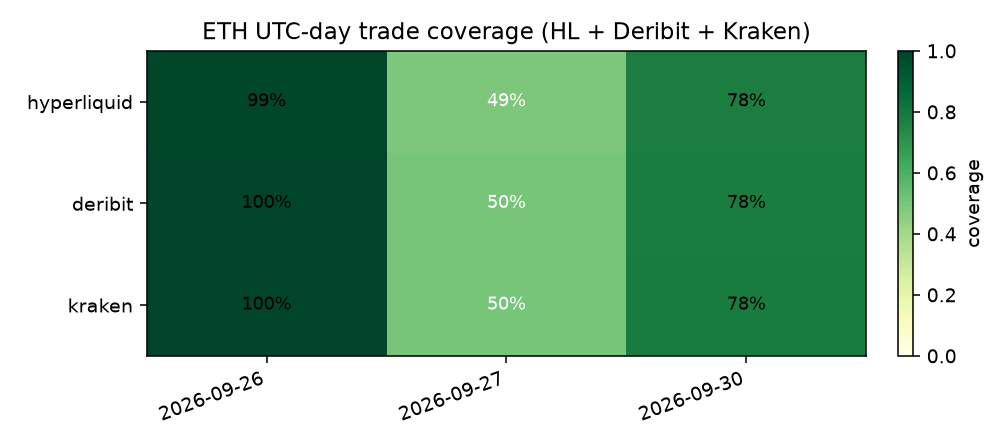

complete venue-days: ['deribit/2026-09-26', 'deribit/2026-09-27', 'deribit/2026-09-30', 'hyperliquid/2026-09-26', 'hyperliquid/2026-09-27', 'hyperliquid/2026-09-30', 'kraken/2026-09-26', 'kraken/2026-09-27', 'kraken/2026-09-30']
flags {'xvenue_confound': True, 'promote_taxonomy': True, 'promote_constraint_hl': False, 'kill_vanity_rdd': True, 'kill_welfare': True, 'kill_sec': True, 'kill_sign_tradable': True}


In [2]:
display(Image(filename=str(FIGS / 'fig_coverage.png')))
print('complete venue-days:', sorted(f"{r.venue}/{r.day}" for _, r in comp[comp.complete].iterrows()))
print('flags', hard.get('flags'))


## Venue τ (absolute tick)

Primary crypto quasi-experiment is the **cross-venue τ gap** (no sovereign LSE-style tick ladder). HL τ≈0.1, Deribit τ≈0.05, Kraken inferred ≈0.1 (trade_synth — fragile).


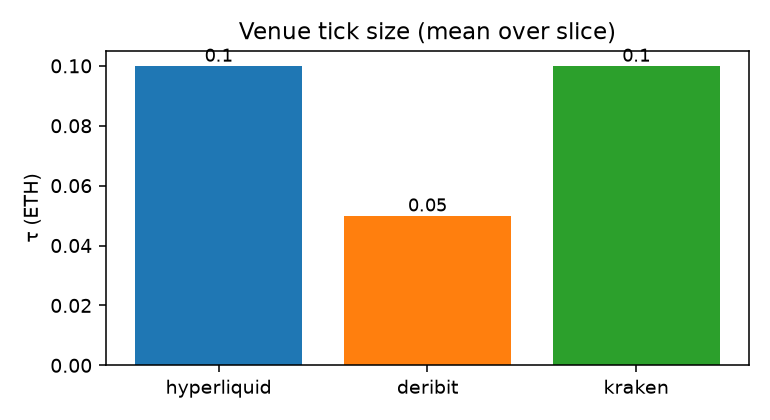

2026-09-26 hyperliquid  tau=0.1 src=known    rel_tick_bps=0.3719 qs_bps=0.372 constr=True
2026-09-26 deribit      tau=0.05 src=known    rel_tick_bps=0.1860 qs_bps=3.725 constr=False
2026-09-26 kraken       tau=0.1 src=inferred rel_tick_bps=0.3720 qs_bps=1.500 constr=False
2026-09-27 hyperliquid  tau=0.1 src=known    rel_tick_bps=0.3717 qs_bps=0.372 constr=True
2026-09-27 deribit      tau=0.05 src=known    rel_tick_bps=0.1858 qs_bps=3.538 constr=False
2026-09-27 kraken       tau=0.1 src=inferred rel_tick_bps=0.3718 qs_bps=1.500 constr=False
2026-09-30 hyperliquid  tau=0.1 src=known    rel_tick_bps=0.3734 qs_bps=0.373 constr=True
2026-09-30 deribit      tau=0.05 src=known    rel_tick_bps=0.1861 qs_bps=1.862 constr=False
2026-09-30 kraken       tau=0.1 src=inferred rel_tick_bps=0.3731 qs_bps=1.500 constr=False


In [3]:
display(Image(filename=str(FIGS / 'fig_venue_tau.png')))
rows = panel['rows']
for r in rows:
    print(f"{r['day']} {r['venue']:12s} tau={r['tau']:.4g} src={r['tau_source']:8s} "
          f"rel_tick_bps={r['rel_tick_bps']:.4f} qs_bps={r['quoted_spread_bps']:.3f} "
          f"constr={r.get('constraint',{}).get('tick_constrained_day')}")


## Research questions (deck → crypto)

| RQ | Deck framing (pp. 20–29) | Crypto mapping |
|----|--------------------------|----------------|
| Large vs small Δτ | Absolute tick cut size flips undercutting | Cross-venue τ gap + within-venue rel-tick moves |
| Relative tick τ/v | Equivalence ↓τ ≈ ↑v for several MQ metrics | `rel_tick = τ/mid` panel (FM) |
| Liquid vs thin | Sign flip on liquid vs less-liquid books | Terciles by spread / depth / intensity |
| Constrained books | Spread ≤ 1–2 ticks → undercutting channel | `tick_constrained` flag (cross-link mmip) |

**Kill / park:** literal LSE GBX / Nasdaq $1 RDD; SEC/IPO channel; welfare.


## Taxonomy vs mmip `tick.*`


,object,mmip,this_book
0,rel_tick / rel_tick_bps,tick.rel_tick_bps (Promote descriptor),panel regressor + sign scorecard
1,frac_one_tick,tick.frac_one_tick (Promote),constraint feature; Hold overlap
2,spread_leeway,tick.spread_leeway (Promote),constraint diagnostics only
3,expected-sign matrix,—,ticksize.expected_sign_matrix (Hold)
4,FM y ~ τ/mid,—,liq.fm_rel_tick_* (Hold; x-venue confound)
5,x-venue τ gap,fragmentation notes,frag.xvenue_tau_gap (Hold)


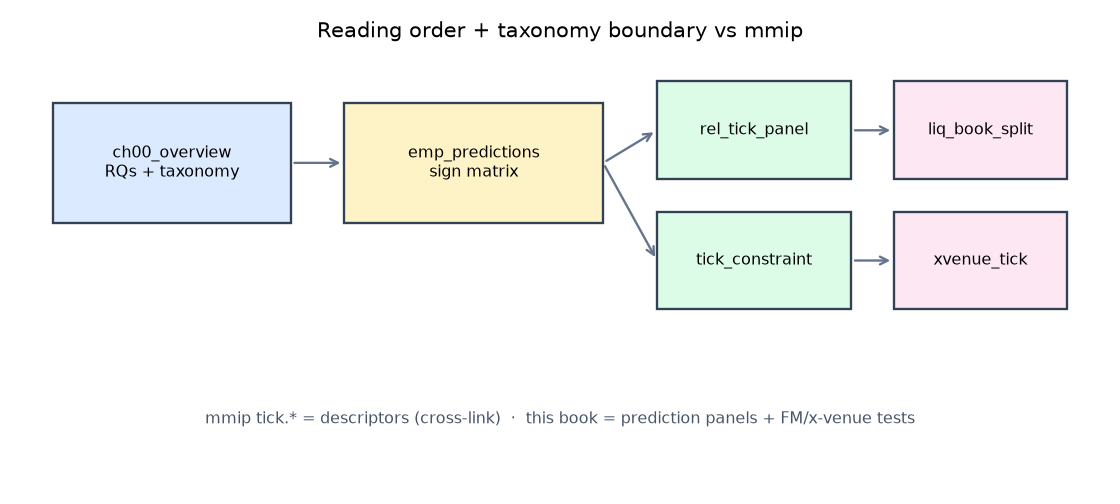

In [4]:
tax = pd.DataFrame([
    {'object': 'rel_tick / rel_tick_bps', 'mmip': 'tick.rel_tick_bps (Promote descriptor)', 'this_book': 'panel regressor + sign scorecard'},
    {'object': 'frac_one_tick', 'mmip': 'tick.frac_one_tick (Promote)', 'this_book': 'constraint feature; Hold overlap'},
    {'object': 'spread_leeway', 'mmip': 'tick.spread_leeway (Promote)', 'this_book': 'constraint diagnostics only'},
    {'object': 'expected-sign matrix', 'mmip': '—', 'this_book': 'ticksize.expected_sign_matrix (Hold)'},
    {'object': 'FM y ~ τ/mid', 'mmip': '—', 'this_book': 'liq.fm_rel_tick_* (Hold; x-venue confound)'},
    {'object': 'x-venue τ gap', 'mmip': 'fragmentation notes', 'this_book': 'frag.xvenue_tau_gap (Hold)'},
])
display(tax)
display(Image(filename=str(FIGS / 'fig_reading_order.png')))


## Reading order

1. **ch00_overview** — RQs, coverage, taxonomy boundary  
2. **emp_predictions** — expected-sign matrix + empirical scorecard; Kill welfare/SEC  
3. **rel_tick_panel** ∥ **tick_constraint** — FM panels / constrained-book channel  
4. **liq_book_split** ∥ **xvenue_tick** — heterogeneity + SOR τ-gap  
5. Hardening → DESK_MEMO + `notebooks/desk_synthesis.ipynb`


## Signal roadmap (desk labels)


In [5]:
board = []
for cid, g in (hard.get('gates') or {}).items():
    board.append({'id': cid, 'decision': g.get('decision'), 'why': g.get('why')})
bdf = pd.DataFrame(board)
print(bdf.to_string(index=False))
print()
print('Promote:', bdf[bdf.decision=='Promote']['id'].tolist())
print('Kill:', bdf[bdf.decision=='Kill']['id'].tolist())


                          id decision                                                                                                                                                  why
       disc.tick_rq_taxonomy  Promote                                                                                                 framing taxonomy vs mmip tick.*; not a numeric claim
   disc.expected_sign_matrix     Hold                                                                                  codified pp.20–29; crypto scorecard hit_rate=0.3333333333333333 n=9
      liq.fm_rel_tick_spread     Hold day FM t=-3.540854265584256; hour FM t=-3.748790878718003; early t=nan late t=-2.0944953638858936; xvenue τ-gap confound — not clean within-venue FM
     liq.rho_rel_tick_spread     Hold                                                                                                              Spearman ρ=-0.6 CI95=[-0.917,0.242] n=9
  exec.tick_constrained_flag     Hold                            

## Inline: coverage × τ cross-check


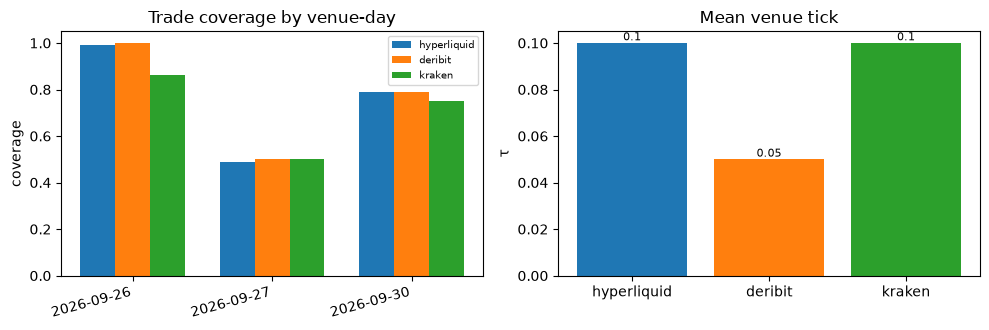

mean coverage 0.741348783436214
Promote taxonomy only — numeric panels live in emp_predictions / rel_tick_panel


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
# coverage bars
days = sorted(comp['day'].unique())
venues = ['hyperliquid', 'deribit', 'kraken']
x = range(len(days))
w = 0.25
for i, v in enumerate(venues):
    vals = [float(comp[(comp.venue==v)&(comp.day==d)]['coverage'].iloc[0]) for d in days]
    axes[0].bar([xi + i*w for xi in x], vals, w, label=v, color={'hyperliquid':'#1f77b4','deribit':'#ff7f0e','kraken':'#2ca02c'}[v])
axes[0].set_xticks([xi + w for xi in x]); axes[0].set_xticklabels(days, rotation=15, ha='right')
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('coverage'); axes[0].set_title('Trade coverage by venue-day')
axes[0].legend(fontsize=7)

tau = comp.groupby('venue')['tau'].mean().reindex(venues)
axes[1].bar(venues, tau.values, color=['#1f77b4','#ff7f0e','#2ca02c'])
axes[1].set_ylabel('τ'); axes[1].set_title('Mean venue tick')
for i, v in enumerate(tau.values):
    axes[1].text(i, v, f'{v:.3g}', ha='center', va='bottom', fontsize=8)
fig.tight_layout(); plt.show()
print('mean coverage', float(comp['coverage'].mean()))
print('Promote taxonomy only — numeric panels live in emp_predictions / rel_tick_panel')


## Promote / Hold / Kill (this chapter)

| ID | Gate |
|----|------|
| `disc.tick_rq_taxonomy` | **Promote** — framing taxonomy vs mmip; not a numeric claim |
| `id.lse_nasdaq_rdd_literal` | **Kill** — no sovereign tick ladder / vanity RD |

Pass checklist: coverage chart ✓ · taxonomy ✓ · reading order ✓ · day-completeness in EXP_REPORT ✓
